# 05 Transformer Model

This notebook is a **local smoke-test version** of a sequence model for volatility forecasting.

Instead of treating each `(Ticker, Date)` row as an independent tabular sample, we feed the model a sequence of the past 60 trading days and ask it to predict the next 5-day realized volatility.

This version is configured for a full local training run with early stopping. It is still small enough to run on your machine, but no longer limited to a tiny smoke test.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Why these features

We keep the feature set intentionally moderate rather than feeding all 90+ engineered columns into the transformer.

The sequence includes four groups of signals:

- stock-specific volatility and activity,
- intraday range,
- market context from broad ETFs,
- macro and credit context from VIX, rates, and bond ETFs.

This is enough to let the model learn time dependencies and regime shifts without making the local smoke test too heavy.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date'])

selected_features = [
    'abs_return',
    'squared_return',
    'high_low_log_range',
    'log_volume',
    'realized_vol_5d',
    'realized_vol_21d',
    'realized_vol_63d',
    'hist_vol_5d',
    'hist_vol_21d',
    'volume_zscore_21d',
    'abs_return_mean_5d',
    'parkinson_vol_5d',
    'mkt_SPY_proxy_return',
    'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return',
    'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d',
    'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return',
    'macro_LQD_proxy_return',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']

transformer_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d'] + selected_features].copy()
transformer_df = transformer_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
transformer_df.head()

,Date,Ticker,fvol_5d,log_fvol_5d,abs_return,squared_return,high_low_log_range,log_volume,realized_vol_5d,realized_vol_21d,...,parkinson_vol_5d,mkt_SPY_proxy_return,mkt_SPY_proxy_hist_vol_5d,mkt_QQQ_proxy_return,mkt_QQQ_proxy_hist_vol_21d,mkt_IWM_proxy_return,macro_^VIX_proxy_level_zscore_21d,macro_^TNX_proxy_return,macro_HYG_proxy_return,macro_LQD_proxy_return
0,2016-04-05,AAPL,0.197562,-1.621702,0.011859,0.000141,0.011901,18.481915,0.181734,0.163209,...,0.139790,-0.010038,0.105989,-0.009688,0.116580,-0.011408,0.023680,-0.052,-0.177803,0.269165
1,2016-04-06,AAPL,0.209733,-1.561921,0.010419,0.000109,0.016169,18.475324,0.152969,0.162645,...,0.138826,0.010862,0.132937,0.016306,0.123577,0.011227,-0.679652,0.028,0.403042,-0.070839
2,2016-04-07,AAPL,0.139626,-1.968790,0.022051,0.000486,0.021050,18.661331,0.215721,0.177386,...,0.160457,-0.012038,0.160427,-0.014471,0.132000,-0.013616,0.708161,-0.064,-0.237087,0.226677
3,2016-04-08,AAPL,0.200380,-1.607538,0.001105,0.000001,0.014683,18.362276,0.205895,0.177400,...,0.157217,0.002693,0.149291,-0.000734,0.131545,0.003949,0.306475,0.029,0.219292,-0.191307
4,2016-04-11,AAPL,0.252147,-1.377742,0.003308,0.000011,0.016223,18.583055,0.194110,0.177762,...,0.155193,-0.002350,0.149090,-0.003677,0.132479,-0.003121,1.222256,0.004,0.065186,-0.007057


## Local smoke-test split

We keep a single train/validation/test split for local training:

- train labels: `2016-2023`,
- validation labels: `2024`,
- test labels: `2025`.

This is still lighter than a full cross-validation workflow, but it is enough to do a meaningful local training run and save a usable baseline.

In [3]:
config = {
    'lookback': 60,
    'batch_size': 512,
    'epochs': 25,
    'patience': 5,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 128,
    'dropout': 0.1,
    'ticker_embedding_dim': 8,
    'train_end_year': 2023,
    'validation_year': 2024,
    'test_year': 2025,
}
config

{'lookback': 60,
 'batch_size': 512,
 'epochs': 25,
 'patience': 5,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'd_model': 64,
 'nhead': 4,
 'num_layers': 2,
 'dim_feedforward': 128,
 'dropout': 0.1,
 'ticker_embedding_dim': 8,
 'train_end_year': 2023,
 'validation_year': 2024,
 'test_year': 2025}

In [4]:
train_mask = transformer_df['Date'].dt.year <= config['train_end_year']
feature_mean = transformer_df.loc[train_mask, selected_features].mean()
feature_std = transformer_df.loc[train_mask, selected_features].std().replace(0, 1).fillna(1)

standardized_df = transformer_df.copy()
standardized_df[selected_features] = (standardized_df[selected_features] - feature_mean) / feature_std

ticker_levels = sorted(standardized_df['Ticker'].unique())
ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}

standardized_df.head()

,Date,Ticker,fvol_5d,log_fvol_5d,abs_return,squared_return,high_low_log_range,log_volume,realized_vol_5d,realized_vol_21d,...,parkinson_vol_5d,mkt_SPY_proxy_return,mkt_SPY_proxy_hist_vol_5d,mkt_QQQ_proxy_return,mkt_QQQ_proxy_hist_vol_21d,mkt_IWM_proxy_return,macro_^VIX_proxy_level_zscore_21d,macro_^TNX_proxy_return,macro_HYG_proxy_return,macro_LQD_proxy_return
0,2016-04-05,AAPL,0.197562,-1.621702,-0.025640,-0.140252,-0.637771,1.918967,-0.312560,-0.598717,...,-0.600002,-0.934388,-0.287116,-0.734069,-0.730643,-0.812649,0.072666,-0.998116,-0.589880,0.523794
1,2016-04-06,AAPL,0.209733,-1.561921,-0.127193,-0.161687,-0.320897,1.913824,-0.477609,-0.602429,...,-0.608870,0.922118,-0.043881,1.106370,-0.664754,0.755964,-0.503542,0.501542,1.233924,-0.151534
2,2016-04-07,AAPL,0.139626,-1.968790,0.692837,0.090587,0.041467,2.058957,-0.117550,-0.505282,...,-0.410000,-1.112030,0.204244,-1.072700,-0.585435,-0.965653,0.633429,-1.223064,-0.776028,0.439402
3,2016-04-08,AAPL,0.200380,-1.607538,-0.783755,-0.233372,-0.431214,1.825617,-0.173929,-0.505187,...,-0.439788,0.196493,0.103731,-0.100065,-0.589721,0.251574,0.304346,0.520289,0.656964,-0.390812
4,2016-04-11,AAPL,0.252147,-1.377742,-0.628480,-0.226880,-0.316853,1.997882,-0.241548,-0.502805,...,-0.458392,-0.251465,0.101917,-0.308435,-0.580925,-0.238345,1.054603,0.051644,0.173084,-0.024848


## Build rolling sequence samples

Each sample uses the previous 60 trading days for one ticker. The target is the log of future 5-day realized volatility at the final day of the input window.

The validation and test windows are allowed to look back into earlier years, which is correct because that information would have been available at prediction time.

In [5]:
grouped_panels = {}
for ticker, group in standardized_df.groupby('Ticker', sort=True):
    group = group.sort_values('Date').reset_index(drop=True)
    grouped_panels[ticker] = {
        'dates': group['Date'].tolist(),
        'features': group[selected_features].to_numpy(dtype=np.float32),
        'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
        'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
    }

class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []

        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                sample_year = panel['dates'][end_idx].year
                if sample_year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=range(2016, config['train_end_year'] + 1))
val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=[config['validation_year']])
test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, config['lookback'], allowed_years=[config['test_year']])

dataset_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'samples': [len(train_dataset), len(val_dataset), len(test_dataset)],
})
dataset_summary

,split,samples
0,train,103400
1,validation,13860
2,test,13475


In [6]:
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)

next(iter(train_loader))['x'].shape

torch.Size([512, 60, 21])

## Transformer encoder with ticker embedding

The sequence model has three parts:

- a linear projection from raw features to the transformer hidden dimension,
- a 2-layer transformer encoder with positional encoding,
- a small head that combines the last sequence state with a ticker embedding and outputs one scalar.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=config['lookback'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

model = VolatilityTransformer(
    input_dim=len(selected_features),
    num_tickers=len(ticker_levels),
    d_model=config['d_model'],
    nhead=config['nhead'],
    num_layers=config['num_layers'],
    dim_feedforward=config['dim_feedforward'],
    dropout=config['dropout'],
    ticker_embedding_dim=config['ticker_embedding_dim'],
).to(DEVICE)

model

VolatilityTransformer(
  (input_proj): Linear(in_features=21, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ticker_embedding): Embedding(55, 8)
  (head): Sequential(
    (0): Linear(in_features=72, out_features=64, bias=Tr

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

def run_epoch(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0

    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = criterion(pred, y_log)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size

    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(pred_log)
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

## Train locally with early stopping

We now run a fuller local training loop:

- maximum `25` epochs,
- early stopping patience of `5`,
- best checkpoint selected by validation loss.

This is enough to make the transformer a real baseline rather than just a smoke test.

In [9]:
history_rows = []
best_state = None
best_val_loss = float('inf')

epochs_without_improvement = 0
best_epoch = None

for epoch in range(1, config['epochs'] + 1):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)
    history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(f"Epoch {epoch}/{config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if epochs_without_improvement >= config['patience']:
        print(f'Early stopping triggered at epoch {epoch}. Best epoch was {best_epoch}.')
        break

history_df = pd.DataFrame(history_rows)
history_df

Epoch 1/25 | train_loss=0.290781 | val_loss=0.246578


Epoch 2/25 | train_loss=0.219612 | val_loss=0.248084


Epoch 3/25 | train_loss=0.208667 | val_loss=0.246373


Epoch 4/25 | train_loss=0.198612 | val_loss=0.255241


Epoch 5/25 | train_loss=0.192276 | val_loss=0.253727


Epoch 6/25 | train_loss=0.187352 | val_loss=0.254027


Epoch 7/25 | train_loss=0.182795 | val_loss=0.252122


Epoch 8/25 | train_loss=0.179180 | val_loss=0.270131
Early stopping triggered at epoch 8. Best epoch was 3.


,epoch,train_loss,val_loss
0,1,0.290781,0.246578
1,2,0.219612,0.248084
2,3,0.208667,0.246373
3,4,0.198612,0.255241
4,5,0.192276,0.253727
5,6,0.187352,0.254027
6,7,0.182795,0.252122
7,8,0.179180,0.270131


In [10]:
if best_state is not None:
    model.load_state_dict(best_state)

val_predictions_df = predict_dataset(model, val_loader)
test_predictions_df = predict_dataset(model, test_loader)

val_metrics_df = pd.DataFrame([volatility_metrics(val_predictions_df['fvol_5d'], val_predictions_df['prediction'])])
test_metrics_df = pd.DataFrame([volatility_metrics(test_predictions_df['fvol_5d'], test_predictions_df['prediction'])])

print('Validation metrics')
display(val_metrics_df)
print('Test metrics')
test_metrics_df

Validation metrics


,rmse,mae,qlike
0,0.143601,0.083634,-1.475956


Test metrics


,rmse,mae,qlike
0,0.172813,0.102842,-1.065429


In [11]:
test_predictions_df.head()

,Date,Ticker,fvol_5d,prediction
0,2025-01-02,AAPL,0.198237,0.138846
1,2025-01-03,AAPL,0.211053,0.121700
2,2025-01-06,AAPL,0.208389,0.121170
3,2025-01-07,AAPL,0.236536,0.125829
4,2025-01-08,AAPL,0.376107,0.126022


## Plot predictions for five representative stocks

This mirrors the earlier notebooks so you can visually compare HAR-RV, Ridge, XGBoost, and Transformer on the same names.

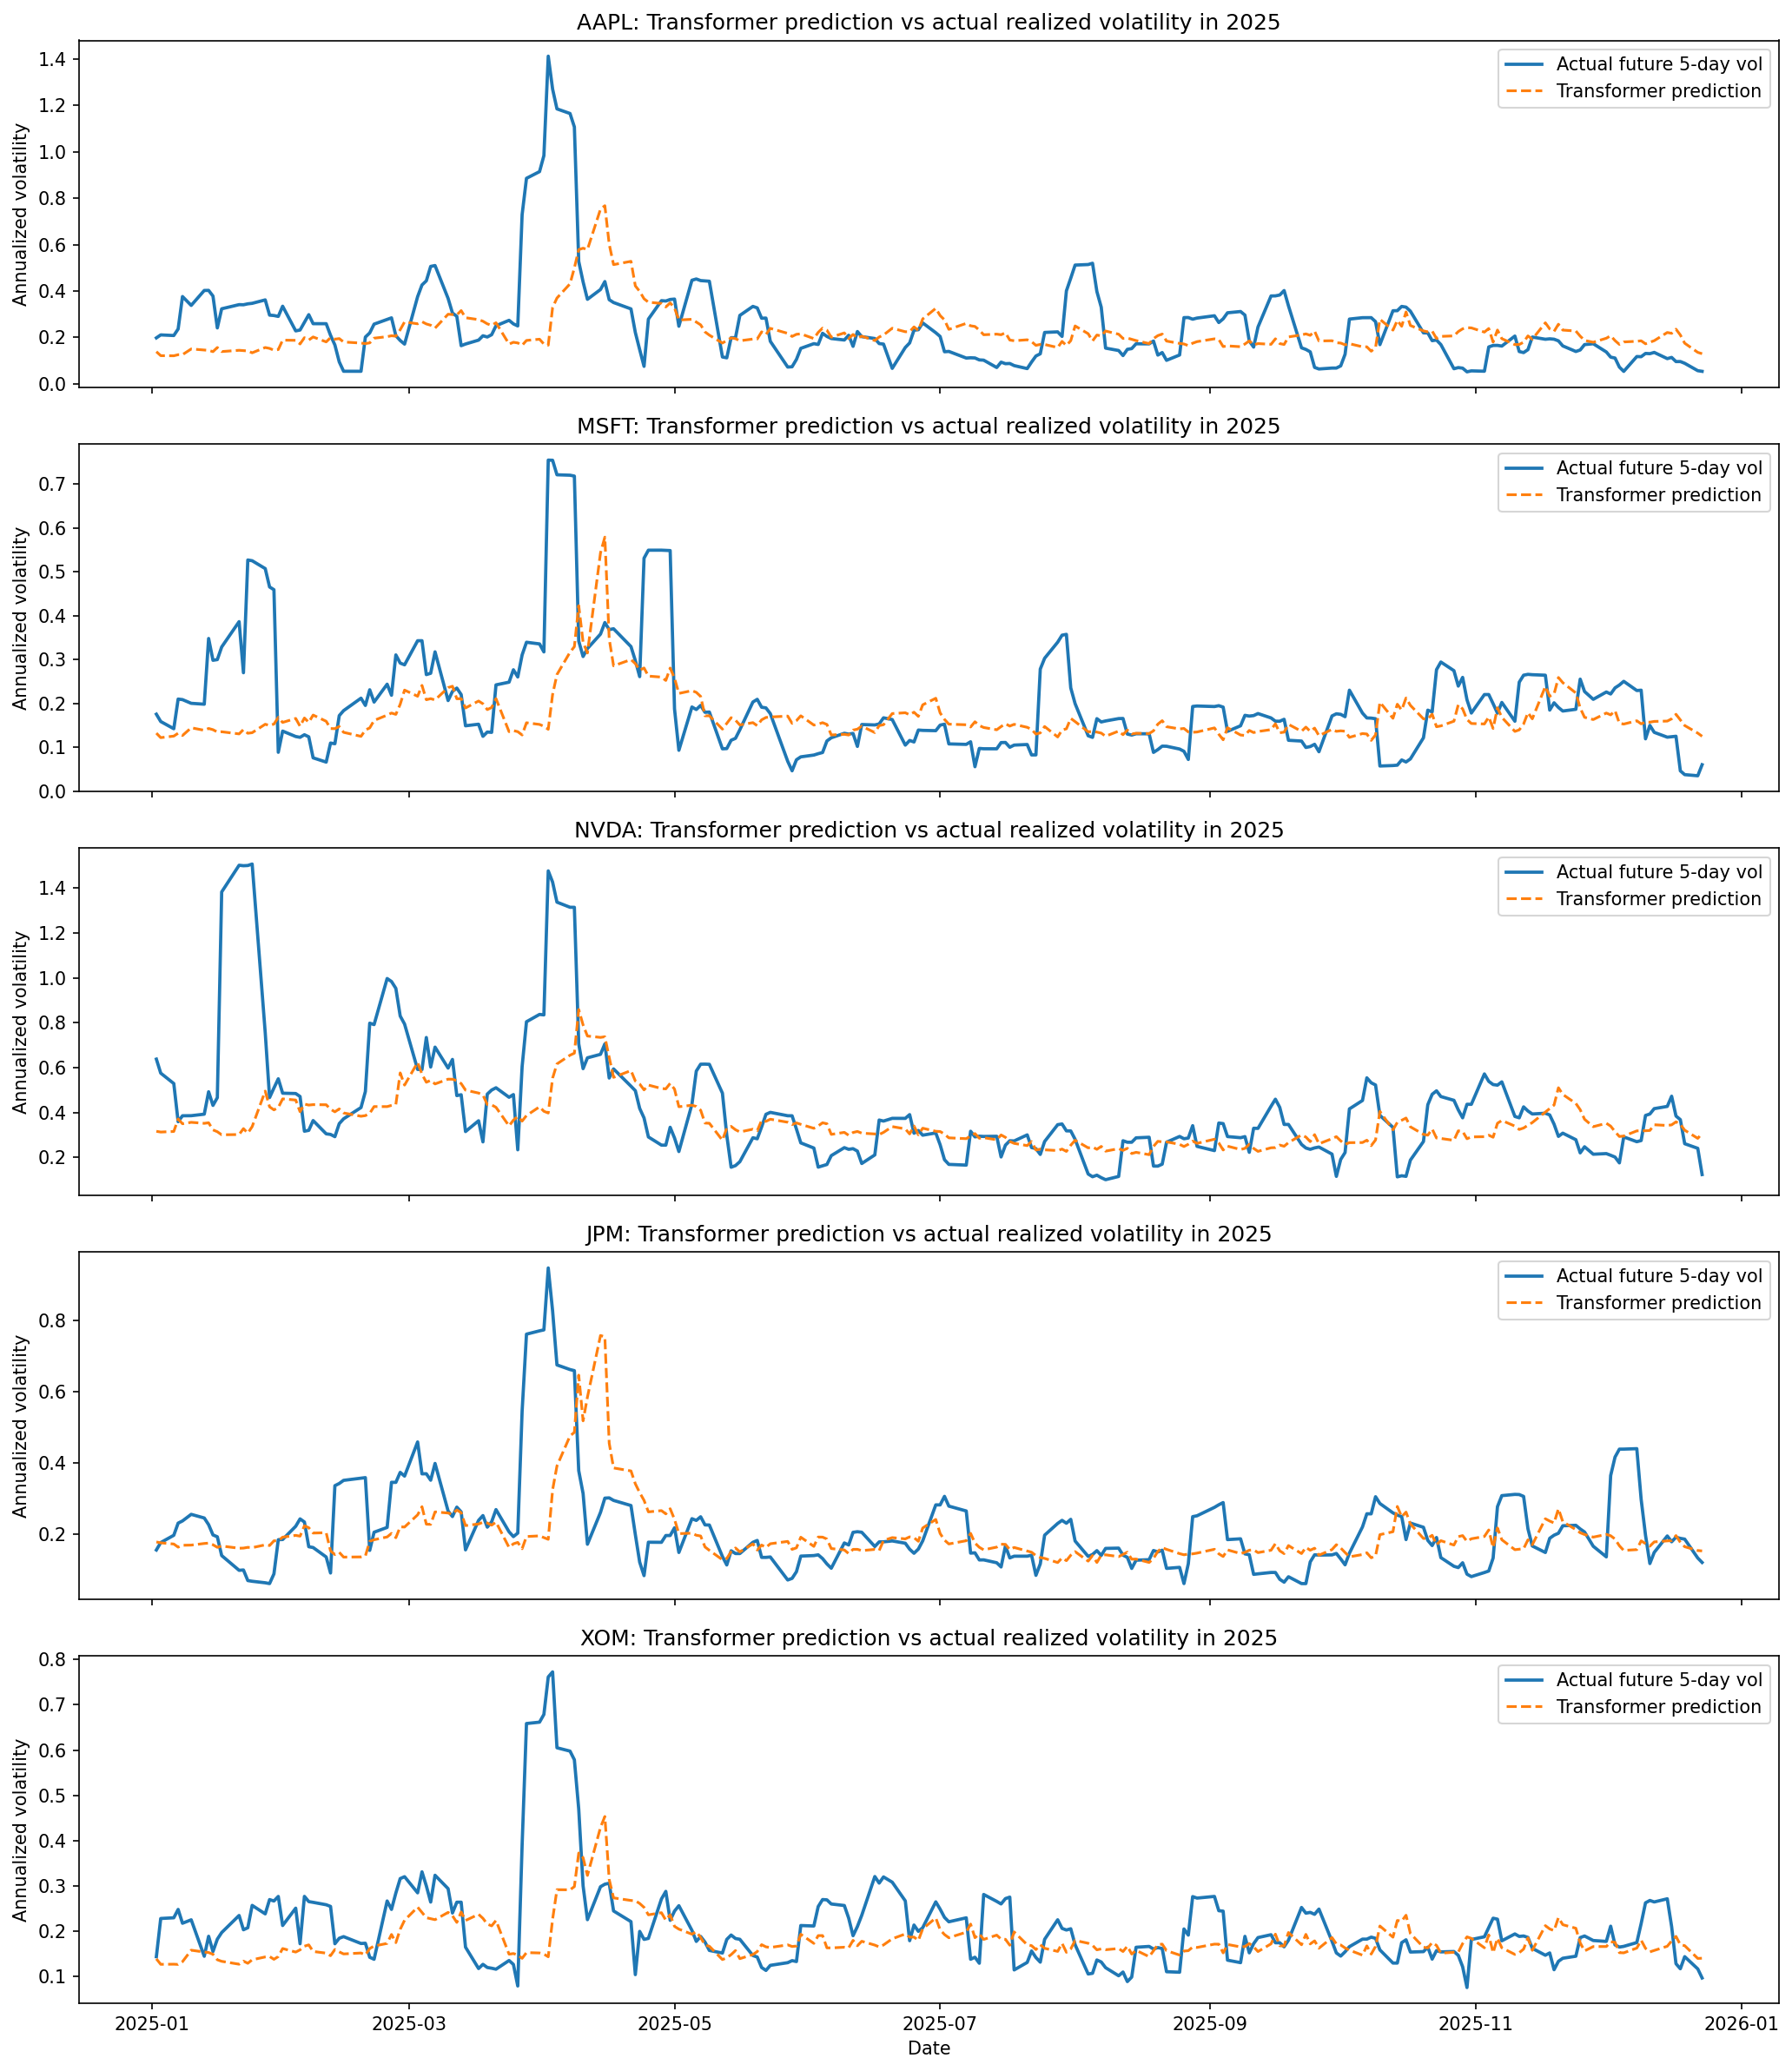

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_test_predictions_5stocks.png')

In [12]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = test_predictions_df[test_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='Transformer prediction', linestyle='--', linewidth=1.5)
    ax.set_title(f'{ticker}: Transformer prediction vs actual realized volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

transformer_plot_path = FIGURE_DIR / 'transformer_test_predictions_5stocks.png'
plt.savefig(transformer_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(transformer_plot_path)))

transformer_plot_path

## What to do on Colab next

This notebook now gives you a usable local baseline. For a stronger Colab run, the next upgrades are:

- move the device to GPU,
- keep early stopping but try a longer epoch budget such as `30-50`,
- experiment with batch size,
- optionally restore a fuller rolling validation setup,
- compare the final metrics against HAR-RV, Ridge, and XGBoost.

If the transformer does not clearly beat XGBoost, that is still a valid result. It means the problem may be explained well enough by tabular nonlinear models.